In [728]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
import pandas as pd 
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import numpy as np 
from itertools import groupby
import requests
from pytimeparse.timeparse import timeparse
from sklearn.metrics import roc_auc_score
import numpy as np 

# Train baseline model with LR

In [751]:
training_data = (
    pd.read_json('../modeling/data/latimes-homepage-placement-labeling.jsonl', lines=True)
#     pd.read_json('../modeling/data/latimes-homepage-placement-labeling-normed.jsonl', lines=True)    
        .assign(date=lambda df: df['homepage_key'].pipe(lambda s: pd.to_datetime(s, format='%Y%m%d%H%M%S')))
)

##  Random Split

In [15]:
train_df, test_df = train_test_split(training_data, train_size=.9)

pipe = Pipeline([
    ('cv', CountVectorizer(min_df=.005, max_df=.5)),
    ('rs', RandomUnderSampler()),
    ('lr', LogisticRegressionCV(max_iter=2_000))
])

pipe.fit(X=train_df['article_text'], y=train_df['label'])

Pipeline(steps=[('cv', CountVectorizer(max_df=0.5, min_df=0.005)),
                ('rs', RandomUnderSampler()),
                ('lr', LogisticRegressionCV(max_iter=2000))])

In [18]:
y_proba = pipe.predict_proba(test_df['article_text'])
y_proba = y_proba[:, 1]
y_proba_df = (pd.Series(y_proba)
    .to_frame('y_prob')
    .assign(y_true=test_df['label'].values)
)

In [22]:
roc_auc_score(y_proba_df['y_true'], y_proba_df['y_prob'])

0.6842609374894096

In [17]:
y_preds = pipe.predict(test_df['article_text'])
f1_score(test_df['label'], y_preds)

0.666771323914181

In [ ]:
f1_score(test_df['label'], [1] * len(test_df))

f1_score(test_df['label'], np.random.choice([0, 1], size=len(test_df)))

In [20]:
# get coefficient matrix
vocab = pd.Series({v:k for k,v in pipe.steps[0][1].vocabulary_.items()}).sort_index()
coef = pipe.steps[2][1].coef_[0]
coef_df = pd.concat([
    (pd.Series(coef, index=vocab)
     .sort_values()
     .head(20).round(3)
     .reset_index()
     .rename(columns={'index': 'word', 0:'strength'})
    ),
    (pd.Series(coef, index=vocab)
     .sort_values()
     .tail(20).round(3)
     .reset_index()
     .rename(columns={'index': 'word', 0:'strength'})
    ),
], axis=1)

coef_df.columns = (pd.MultiIndex
 .from_product([('bottom coefficients', 'top coefficients'), coef_df.columns[:2]])
)

coef_df.head(10)

bottom coefficients          top coefficients         
                 word strength             word strength
0          newsletter   -0.153          privacy    0.058
1                info   -0.143      immediately    0.059
2              writes   -0.093             plot    0.059
3             caption   -0.093             plea    0.059
4                ktla   -0.084             date    0.059
5                link   -0.083             host    0.059
6             recipes   -0.080            sandy    0.059
7             article   -0.079             nato    0.060
8         subscribing   -0.079           rating    0.060
9              travel   -0.073          twitter    0.062

## Time Based Split

In [738]:
from datetime import datetime
train_df = training_data.loc[lambda df: df['date'] <= datetime(2018, 1, 1)]
test_df = training_data.loc[lambda df: df['date'] > datetime(2018, 1, 1)]

In [597]:
pipe = Pipeline([
    ('cv', CountVectorizer(min_df=.005, max_df=.5)),
    ('rs', RandomUnderSampler()),
    ('lr', LogisticRegressionCV(max_iter=2_000))
])

pipe.fit(X=train_df['normalized_text'], y=train_df['label'])

Pipeline(steps=[('cv', CountVectorizer(max_df=0.5, min_df=0.005)),
                ('rs', RandomUnderSampler()),
                ('lr', LogisticRegressionCV(max_iter=2000))])

In [598]:
y_preds = pipe.predict(test_df['normalized_text'])
y_proba = pipe.predict_proba(test_df['normalized_text'])
y_proba = y_proba[:, 1]
y_proba_df = (pd.Series(y_proba)
 .to_frame('y_prob')
 .assign(y_true=test_df['label'].values)
)

f1_scores = {}
for i in np.arange(0, 1, .01):
    f1_scores[i] = (
        y_proba_df
         .assign(y_pred=lambda df: df['y_prob'] > i)
         .pipe(lambda df: f1_score(df['y_true'], df['y_pred']))
        )

0.521531100478469

In [602]:
roc_auc_score(y_proba_df['y_true'], y_proba_df['y_prob'])

0.5480991377054635

In [ ]:
roc_auc_score(test_df['label'], np.random.rand(len(test_df)))

# get coefficient matrix
vocab = pd.Series({v:k for k,v in pipe.steps[0][1].vocabulary_.items()}).sort_index()

coef = pipe.steps[2][1].coef_[0]

coef_df = pd.concat([
    (pd.Series(coef, index=vocab)
     .sort_values()
     .head(20).round(3)
     .reset_index()
     .rename(columns={'index': 'word', 0:'strength'})
    ),
    (pd.Series(coef, index=vocab)
     .sort_values()
     .tail(20).round(3)
     .reset_index()
     .rename(columns={'index': 'word', 0:'strength'})
    ),
], axis=1)

coef_df.columns = (pd.MultiIndex
 .from_product([('bottom coefficients', 'top coefficients'), coef_df.columns[:2]])
)

coef_df.head(10)

# Fit with Beta Regression

In [72]:
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression

class LogitRegression(LinearRegression):    
    epsilon = .001
    
    def fit(self, x, p):
        p = np.asarray(p)
        p = np.minimum(p, 1-self.epsilon)
        p = np.maximum(p, self.epsilon)
        y = np.log(p / (1 - p))
        return super().fit(x, y)

    def predict(self, x):
        y = super().predict(x)
        return 1 / (np.exp(-y) + 1)

In [66]:
pipe = Pipeline([
    ('cv', CountVectorizer(min_df=.005, max_df=.5)),
    ('lr', LogitRegression())
])

In [67]:
pipe.fit(X=train_df['article_text'], y=train_df['perc_height'])

Pipeline(steps=[('cv', CountVectorizer(max_df=0.5, min_df=0.005)),
                ('lr', LogitRegression())])

In [68]:
y_preds = pipe.predict(test_df['article_text'])

In [80]:
test_df.assign(y_preds=y_preds)[['y_preds', 'perc_height']].corr()

,y_preds,perc_height
y_preds,1.000000,0.100024
perc_height,0.100024,1.000000


In [112]:
bins = [0, .1, .2, .4, .8]
pipe = Pipeline([
    ('cv', CountVectorizer(min_df=.005, max_df=.5)),
    ('rs', RandomUnderSampler()),
    ('lr', LogisticRegressionCV(max_iter=2_000))
])

In [114]:
train_df = train_df.assign(label=lambda df: pd.cut(df['perc_height'], bins=bins, right=False).astype(str)).dropna()

In [ ]:
pipe.fit(X=train_df['article_text'], y=train_df['label'])

In [ ]:
test_df = test_df.assign(label=lambda df: pd.cut(df['perc_height'], bins=bins, right=False).astype(str)).dropna()

In [ ]:
pipe.predict(X=test_df['article_text'])

# Use new processed training data

In [854]:
training_data = (
    pd.read_json('../modeling/data/latimes-homepage-placement-labeling-no-article-filter.jsonl', lines=True)
        .assign(date=lambda df: df['homepage_key'].pipe(lambda s: pd.to_datetime(s, format='%Y%m%d%H%M%S')))              
)

In [ ]:
# training_data = (training_data
#  .pipe(lambda df: 
#       pd.concat([
#           df.groupby('article_url')['homepage_key'].aggregate(list).to_frame('homepage_keys'),
#           df.groupby('article_url')['article_text'].aggregate(list).str.get(0).to_frame('article_text'),
#           df.groupby('article_url')[['perc_height', 'perc_width', 'area', 'width', 'height', 'x', 'y']].mean()          
#       ], axis=1)
#   )
# )

In [803]:
import ast
from datetime import datetime

<AxesSubplot:>

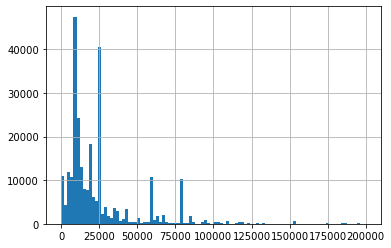

In [868]:
# training_data['area'].apply(np.log).loc[lambda s: s > 0].hist(bins=100)#, range=(0, 200_000))
training_data['area'].hist(bins=100, range=(0, 200_000))

In [ ]:
top_screen = [(1024, 768)]

In [886]:
training_data.loc[lambda df: df['y'] < 768].shape 

(23675, 13)

In [1003]:
from datetime import datetime
threshold = 1_000
train_df, test_df = (
    training_data
    .loc[lambda df: df['area'] > 10_000]
    .loc[lambda df: df['y'] < (threshold * 2)]
    .assign(label=lambda df: (df['y'] < threshold).astype(int))
    .pipe(lambda df: 
         (df.loc[lambda df: df['date'] <= datetime(2018, 1, 1)],
          df.loc[lambda df: df['date'] > datetime(2018, 1, 1)]
         )
     )
    
)

In [1004]:
train_dat = (train_df
 .apply(lambda x: f"__label__{x['label']} {' '.join(x['sentences'][:10])}", axis=1)
 .tolist()
)

with open('cache/fasttext-train.txt', 'w') as f:
    for line in train_dat:
        f.write(line)
        f.write('\n')

In [1005]:
import fasttext

In [1006]:
model = fasttext.train_supervised('cache/fasttext-train.txt')

Read 5M words
Number of words:  233255
Number of labels: 2
Progress: 100.0% words/sec/thread: 3402444 lr:  0.000000 avg.loss:  0.632686 ETA:   0h 0m 0s


In [1007]:
output = model.predict(test_df['sentences'].apply(lambda x: ' '.join(x[:10])).tolist(), k=2)

In [1008]:
test_df['label'].value_counts()

0    6734
1    5495
Name: label, dtype: int64

In [1009]:
pred_label = pd.Series(output[0]).apply(lambda x: x[0].replace('__label__','')).astype(int)

In [1010]:
f1_score(test_df['label'], pred_label)

0.31016714842277243

In [991]:
roc_auc_score(test_df, pd.DataFrame(output[1])[1], )

0        0.455169
1        0.342488
2        0.291391
3        0.281202
4        0.307945
           ...   
12224    0.173856
12225    0.173856
12226    0.173856
12227    0.173856
12228    0.124816
Name: 1, Length: 12229, dtype: float32

# Prepare dataset for GPT3

In [1027]:
threshold = 1_500
training_data_for_gpt3, test_data_for_gpt3 = (
    training_data
    .loc[lambda df: df['area'] > 10_000]
    .loc[lambda df: df['y'] < (threshold * 2)]
    .pipe(lambda df: 
         (df.loc[lambda df: df['date'] <= datetime(2018, 1, 1)],
          df.loc[lambda df: df['date'] > datetime(2018, 1, 1)]
         )
     )
)

In [ ]:
training_data_for_gpt3['homepage_key'].unique().shape

In [1056]:
def generate_training_pairs(df, num_samples=100):
    output_samples = []
    num_samples = min(len(df) * 2, num_samples)
    while len(output_samples) < num_samples:
        pair = df.sample(2).sort_values('x')
        if pair.iloc[0]['y'] < pair.iloc[1]['y']:
            output_samples.append({
                'more_newsworthy_article': pair.iloc[0]['sentences'],
                'less_newsworthy_article': pair.iloc[1]['sentences'],
                'homepage': df.sample(len(df))['sentences'].tolist()
            })
    return output_samples

In [1059]:
all_gpt3_training_data = []
homepage_keys = training_data_for_gpt3['homepage_key'].drop_duplicates()
for key in tqdm(homepage_keys, total=len(homepage_keys)):
    df = training_data_for_gpt3.loc[lambda df: df['homepage_key'] == key]
    one_hp_training_data = generate_training_pairs(df)
    all_gpt3_training_data.append(one_hp_training_data)

  0%|          | 0/2057 [00:00<?, ?it/s]

In [1066]:
from more_itertools import flatten

all_gpt3_training_data = list(flatten(all_gpt3_training_data))

In [1141]:
all_gpt3_training_data_df = (pd.DataFrame(all_gpt3_training_data)
 .assign(more_newsworthy_article=lambda df: df['more_newsworthy_article'].apply(lambda x: x[:5]).str.join(' '))
 .assign(less_newsworthy_article=lambda df: df['less_newsworthy_article'].apply(lambda x: x[:5]).str.join(' '))
 .drop_duplicates(['more_newsworthy_article', 'less_newsworthy_article'])
 .assign(homepage=lambda df: 
         df['homepage']
         .apply(lambda x: list(map(lambda y: y[0] if len(y) > 0 else '', x)))
         .str.join(' ||| ')
        )
)

to_filter = ['may no longer exist', 'Comments are filtered']
for f in to_filter:
    all_gpt3_training_data_df = (all_gpt3_training_data_df 
         .loc[lambda df: ~df['less_newsworthy_article'].str.contains(f)]
         .loc[lambda df: ~df['more_newsworthy_article'].str.contains(f)]
    )

In [1142]:
import random
def make_prompt(datum, include_homepage_context=False):
    first, second = datum['more_newsworthy_article'], datum['less_newsworthy_article']
    label = (random.random() < .5)
    if label == False:
        first, second = second, first
    prompt = f'First article: \n\n"{first}"\n\n Second article: \n\n {second}'
    if include_homepage_context:
        prompt += f'\n\nRest of Homepage: {datum["homepage"]} '
    
    prompt += '\n\nWhich article is more newsworthy?'
    completion = '\n\n First' if label else '\n\n Second'
    return {'prompt': prompt, 'completion': completion}

In [1147]:
prompt_completions_no_context = all_gpt3_training_data_df.apply(make_prompt, axis=1)

prompt_completions_context = all_gpt3_training_data_df.apply(make_prompt, axis=1, include_homepage_context=True)

(prompt_completions_no_context
 .to_json(
     '../modeling/pairwise-comparison-homepage-model/gpt3-pairwise-model-no-context.jsonl', 
     orient='records', 
     lines=True
 )
)
# ft-nU9d21Lo4BnU9YvyJHvnpF4g

(prompt_completions_context
 .to_json(
     '../modeling/pairwise-comparison-homepage-model/gpt3-pairwise-model-hp-context.jsonl', 
     orient='records', 
     lines=True
 )
)
# ft-3bZIGMd9bd3nTIYHpLjTeB2u

In [1171]:
test_data_for_gpt3.head(2)

,article_url,homepage_key,article_text,perc_height,perc_width,label,area,width,height,x,y,sentences,date
84099,http://www.latimes.com/la-me-southern-californ...,20180109185313,"Just before 9 a.m., Caltrans worker Demauriel ...",0.024797,0.03125,True,92400.0,1200.0,77.0,40.0,394.5,"[Just before 9 a. m., Caltrans worker Demaurie...",2018-01-09 18:53:13
84118,http://www.latimes.com/politics/la-na-pol-trum...,20180123080435,"""We're going to show great heart,"" he vowed, g...",0.118500,0.05000,True,33108.0,744.0,44.5,64.0,821.5,"[""We're going to show great heart,"" he vowed, ...",2018-01-23 08:04:35


In [1173]:
import openai

In [1174]:
openai.api_key_path = "/Users/spangher/.openai-isi-key.txt"

In [ ]:
openai.FineTune.list()

In [1202]:
no_context_model_id = 'ft-nU9d21Lo4BnU9YvyJHvnpF4g'
no_context_model_name = 'babbage:ft-isi-nlp-2023-03-15-06-46-17'

In [1179]:
all_gpt3_test_data = []
homepage_keys = test_data_for_gpt3['homepage_key'].drop_duplicates()
for key in tqdm(homepage_keys, total=len(homepage_keys)):
    df = test_data_for_gpt3.loc[lambda df: df['homepage_key'] == key]
    one_hp_test_data = generate_training_pairs(df)
    all_gpt3_test_data.append(one_hp_test_data)

  0%|          | 0/646 [00:00<?, ?it/s]

In [ ]:
all_gpt3_test_data = list(flatten(all_gpt3_test_data))
all_gpt3_test_data_df = (pd.DataFrame(all_gpt3_test_data)
 .assign(more_newsworthy_article=lambda df: df['more_newsworthy_article'].apply(lambda x: x[:5]).str.join(' '))
 .assign(less_newsworthy_article=lambda df: df['less_newsworthy_article'].apply(lambda x: x[:5]).str.join(' '))
 .drop_duplicates(['more_newsworthy_article', 'less_newsworthy_article'])
 .assign(homepage=lambda df: 
         df['homepage']
         .apply(lambda x: list(map(lambda y: y[0] if len(y) > 0 else '', x)))
         .str.join(' ||| ')
        )
)

to_filter = ['may no longer exist', 'Comments are filtered']
for f in to_filter:
    all_gpt3_test_data_df = (all_gpt3_test_data_df 
         .loc[lambda df: ~df['less_newsworthy_article'].str.contains(f)]
         .loc[lambda df: ~df['more_newsworthy_article'].str.contains(f)]
    )

In [1190]:
test_prompt_completions_no_context = all_gpt3_test_data_df.apply(make_prompt, axis=1)

In [1274]:
test_prompt_completions_hp_context = all_gpt3_test_data_df.apply(
    make_prompt, include_homepage_context=True, axis=1)

In [1195]:
to_test = test_prompt_completions_no_context.sample(5_000)
test_batch_completions = []
for prompt in tqdm(to_test.apply(lambda x: x['prompt'])):
    completion = openai.Completion.create(
          model=no_context_model_name,
          prompt=prompt,
          max_tokens=5
        )

    completion_text = completion.to_dict_recursive()['choices'][0]['text'].strip()
    test_batch_completions.append(completion_text)

In [1291]:
gpt3_preds = pd.Series(test_batch_completions)
y_true = to_test.apply(lambda x: x['completion']).str.strip()
y_true.value_counts()

First     2515
Second    2485
dtype: int64

In [1293]:
gpt3_preds.apply(lambda x: 'Second' if 'Second' in x else 'First').value_counts()

First     2527
Second    2473
dtype: int64

In [1265]:
results_df = pd.concat([
    to_test.apply(lambda x: x['prompt']).str.strip().to_frame('prompt').reset_index(drop=True),
    y_true.to_frame('y_true').reset_index(drop=True),
    gpt3_preds.apply(lambda x: 'First' if 'First' in x else 'Second').to_frame('y_pred')
], axis=1)

In [1313]:
results_df = pd.read_csv('../modeling/pairwise-comparison-homepage-model/gpt3-pairwise-no-context-results.csv')

In [1318]:
results_df.apply(lambda x: x['y_true'] == x['y_pred'], axis=1).mean()

0.6174

In [ ]:
naive_gpt3_test_batch_completions = []
for prompt in tqdm(to_test.apply(lambda x: x['prompt'])):
    completion = openai.Completion.create(
          model="text-davinci-003",
          prompt=prompt,
          max_tokens=5
        )

    completion_text = completion.to_dict_recursive()['choices'][0]['text'].strip()
    naive_gpt3_test_batch_completions.append(completion_text)

In [1256]:
gpt3_naive_preds = pd.Series(naive_gpt3_test_batch_completions)

In [1269]:
naive_results_df = pd.concat([
    to_test.apply(lambda x: x['prompt']).str.strip().to_frame('prompt').reset_index(drop=True),
    y_true.to_frame('y_true').reset_index(drop=True),
    gpt3_naive_preds.apply(lambda x: 'First' if 'First' in x else 'Second').to_frame('y_pred')
], axis=1).dropna()

In [1312]:
naive_results_df.apply(lambda x: x['y_true'] == x['y_pred'], axis=1).mean()

0.5044330377974802

In [1273]:
naive_results_df.to_csv('../modeling/pairwise-comparison-homepage-model/gpt3-pairwise-no-context-naive-gpt3-results.csv')

In [1277]:
hp_context_model_name = "babbage:ft-isi-nlp-2023-03-16-11-54-14"

In [1281]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('gpt2')

In [ ]:
to_test = test_prompt_completions_hp_context.sample(5_000)
hp_context_test_batch_completions = []

In [1282]:
for prompt in tqdm(to_test.apply(lambda x: x['prompt']).iloc[len(hp_context_test_batch_completions):]):
    if len(tokenizer.encode(prompt)) > 2040:
        completion_text = ''
    else:
        completion = openai.Completion.create(
              model=hp_context_model_name,
              prompt=prompt,
              max_tokens=5
            )

        completion_text = completion.to_dict_recursive()['choices'][0]['text'].strip()
    hp_context_test_batch_completions.append(completion_text)

  0%|          | 0/4025 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2093 > 1024). Running this sequence through the model will result in indexing errors


In [1295]:
gpt3_preds_hp_context = pd.Series(hp_context_test_batch_completions)
y_true = to_test.apply(lambda x: x['completion']).str.strip()
y_true.value_counts()

First     2515
Second    2485
dtype: int64

In [1303]:
results_hp_context_df = pd.concat([
    to_test.apply(lambda x: x['prompt']).str.strip().to_frame('prompt').reset_index(drop=True),
    y_true.to_frame('y_true').reset_index(drop=True),
    gpt3_preds_hp_context.apply(lambda x: 'First' if 'First' in x else 'Second').to_frame('y_pred')
], axis=1).dropna()

In [1319]:
results_hp_context_df.apply(lambda x: x['y_true'] == x['y_pred'], axis=1).mean()

0.6066

In [1310]:
gpt3_preds_hp_context.to_csv('../modeling/pairwise-comparison-homepage-model/gpt3-pairwise-hp-context.csv')

In [ ]:
# todo list: 
#   newsworthiness detection for articles:
#   ----------------------------------------------------------------------------------
#   retrain GPT3 models on the SF Chron
#   test them on the SF Chron, too
#   train models to do absolute positioning (left, middle, right)?

#   newsworthiness detection for city council meeting minutes
#   ----------------------------------------------------------------------------------

#   1. summarize city-council meeting minutes using GPT3
#       -> use GPT3 to extract major different events involved.
#   2. link city-council meeting minutes naively to articles using NERs and filtering articles to a time-range
#   3. build text models to see whether GPT3 can classify minutes as having been written about or not
#        -> Does this work better for summaries or for whole minutes? 
#   4. test how well the newsworthiness models re-order city-council meeting minutes
#        -> Does this work better for summaries or for whole minutes?

In [1324]:
print("First article: \n\n\"David Hegarty plays the Wurlitzer organ this month before a screening at the Castro Theatre. Hegarty has been the theater's principal organist since 1983. The Mighty Wurlitzer rises from its pit to the stage of the Castro Theatre, and David Hegarty is working the levers and keys and switches and pedals to pump out the show tunes, just as he has done almost every night for 30 years. To continue reading this story, you will need to be a digital subscriber to SFChronicle. com.\"\n\n Second article: \n\n The scene that day in January was pretty remarkable: During his swearing-in ceremony, newly re-elected Oakland City Councilman Larry Reid began his speech by calling to the podium a man he called his dear friend, a man so close to him he was considered family. To continue reading this story, you will need to be a digital subscriber to SFChronicle. com.\n\nRest of Homepage: Moved Permanently The document has moved here. ||| Tony Dominski of Pacifica represents the namesake of Devil's Slide at the invitation-only event to mark the opening of the 4,200-foot tunnel on Highway 1 along the San Mateo County coast. ||| The fire at the Chevron refinery in Richmond last August sent thousands of East Bay residents to emergency rooms with respiratory problems. ||| Moved Permanently The document has moved here. ||| David Hegarty plays the Wurlitzer organ this month before a screening at the Castro Theatre. ||| Moved Permanently The document has moved here. ||| Activated? ||| Activated? ||| The scene that day in January was pretty remarkable: During his swearing-in ceremony, newly re-elected Oakland City Councilman Larry Reid began his speech by calling to the podium a man he called his dear friend, a man so close to him he was considered family. ||| Moved Permanently The document has moved here. ||| Sen. Rand Paul, R-Ky., believes that Congress is \"about 10 years behind the public.\" ||| Net Worth - Kathleen Pender Target may edge out Sears in San Mateo A preliminary planning application to the city of San Mateo last week calls for replacing the Sears store in Hillsdale Shopping Center with a Target, adding a nine-screen luxury cinema and building a stand-alone building with about 11,000 square feet of retail space. ||| Moved Permanently The document has moved here. ||| Already Activated? \n\nWhich article is more newsworthy?")

First article: 

"David Hegarty plays the Wurlitzer organ this month before a screening at the Castro Theatre. Hegarty has been the theater's principal organist since 1983. The Mighty Wurlitzer rises from its pit to the stage of the Castro Theatre, and David Hegarty is working the levers and keys and switches and pedals to pump out the show tunes, just as he has done almost every night for 30 years. To continue reading this story, you will need to be a digital subscriber to SFChronicle. com."

 Second article: 

 The scene that day in January was pretty remarkable: During his swearing-in ceremony, newly re-elected Oakland City Councilman Larry Reid began his speech by calling to the podium a man he called his dear friend, a man so close to him he was considered family. To continue reading this story, you will need to be a digital subscriber to SFChronicle. com.

Rest of Homepage: Moved Permanently The document has moved here. ||| Tony Dominski of Pacifica represents the namesake of Dev

In [758]:
url = training_data['article_url'][0]

In [776]:
training_data.iloc[0]

article_url     http://www.latimes.com/health/dentalhealth/hk-...
homepage_key                                       20110801000132
article_text    Dental Health\n\nBraces aren't just for kids a...
perc_height                                                   0.0
perc_width                                               0.132392
label                                                        True
area                                                     210210.0
width                                                       980.0
height                                                      214.5
x                                                           150.0
y                                                             0.0
sentences       [Dental Health Braces aren't just for kids any...
date                                          2011-08-01 00:01:32
Name: 0, dtype: object

# Filter to the articles most relevant to AgendaWatch

In [29]:
import pandas as pd 
agenda_watch_df = pd.read_csv('../data/agenda-watch-bay-area-202027.csv', index_col=0)

In [177]:
import spacy
spacy_model = spacy.load('en_core_web_lg')

In [568]:
from tqdm.auto import tqdm
import re
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.csr import csr_matrix
from number_parser import parse as parse_numbers, parse_ordinal

def array_to_words(arr):
    if isinstance(arr, csr_matrix):
        arr = arr.todense()
    if isinstance(arr, np_matrix):
        arr = np.array(arr)
    if len(arr.shape) == 2:
        arr = arr[0]
        
    active_indices = np.where(arr > 0)[0]
    return list(map(inverse_vocab.get, active_indices))

def remove_numbers(doc_str):
#     doc_str = parse_numbers(doc_str)
    doc_str = re.sub(r'\b\d+\b', 'NUM', doc_str)
    doc_str = re.sub(r'\d+(rd|th|rd|st)\b', 'NUM', doc_str)
    return doc_str

def normalize_text_list(text_list):
    normalized_docs = []

    for doc in tqdm(spacy_model.pipe(
        text_list,
        disable=["tok2vec", "tagger", "parser", "attribute_ruler", "lemmatizer"]
    ), total=len(text_list)):
        doc_str = str(doc)
        for e in doc.ents:
            doc_str = re.sub(fr'\b{re.escape(str(e))}\b', ' ' + e.label_ + ' ', doc_str)
#         doc_str = parse_numbers(doc_str)
        doc_str = re.sub(r'\b\d+\b', ' NUM ', doc_str)
        doc_str = re.sub(r'\d+(rd|th|rd|st)\b', ' NUM ', doc_str)
        doc_str = re.sub('\_+', ' ', doc_str)
        doc_str = re.sub('\s+', ' ', doc_str)
        normalized_docs.append(doc_str)
    return normalized_docs

In [281]:
agenda_watch_df['normalized_text'] = normalize_text_list(agenda_watch_df['text'])

  0%|          | 0/1073 [00:00<?, ?it/s]

In [282]:
training_data['normalized_text'] = normalize_text_list(training_data['article_text'])

  0%|          | 0/173561 [00:00<?, ?it/s]

In [526]:
# training_data.to_json('../modeling/data/latimes-homepage-placement-labeling-normed.jsonl', lines=True, orient='records')

In [549]:
from sklearn.feature_extraction._stop_words import ENGLISH_STOP_WORDS

In [655]:
stop_words = list(ENGLISH_STOP_WORDS)
stop_words += [
    'ordinal', 'person', 'date', 'gpe', 'org', 'fac', 'www', 'com', 'said', 'loc', 'norp',
    'http', 'times', 'like'
]

In [656]:
agenda_watch_cv = CountVectorizer(min_df=.0005, max_df=.7, stop_words=stop_words)
agenda_watch_vectors = agenda_watch_cv.fit_transform(agenda_watch_df['normalized_text'])
inverse_vocab = {v:k for k,v in agenda_watch_cv.vocabulary_.items()}

In [657]:
training_article_vectors = agenda_watch_cv.transform(training_data['normalized_text'])

In [589]:
cosine_df = pd.DataFrame(cosine_similarity(training_article_vectors, agenda_watch_vectors))

<AxesSubplot:>

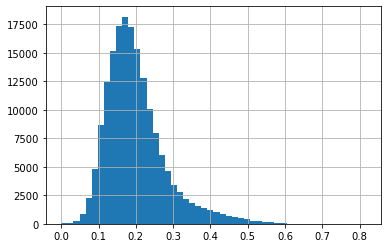

In [609]:
cosine_df.max(axis=1).hist(bins=50)

In [612]:
idx_to_get = cosine_df.iloc[1].idxmax()

In [613]:
a_words = array_to_words(agenda_watch_vectors[idx_to_get])

In [584]:
t_words = array_to_words(training_article_vectors[1])

In [658]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=10)
lda.fit(training_article_vectors)
topic_matrix = pd.DataFrame(
    lda.exp_dirichlet_component_,
    columns=pd.Series({v:k for k,v in agenda_watch_cv.vocabulary_.items()}).sort_index().values
).T

LatentDirichletAllocation()

In [660]:
topic_df = {}
for topic_i in topic_matrix.columns:
    topic_df[topic_i] = topic_matrix[topic_i].sort_values(ascending=False).head(5).index

In [662]:
pd.DataFrame(topic_df).rename(columns=lambda x: 'topic %s' % x)

,topic 0,topic 1,topic 2,topic 3,topic 4,topic 5,topic 6,topic 7,topic 8,topic 9
0,president,quantity,advertisement,money,just,game,city,school,work_of_art,police
1,state,home,people,company,people,team,state,students,new,man
2,law,people,health,product,says,product,officials,children,movie,officers
3,campaign,water,state,million,don,event,government,parents,music,according
4,political,area,covid,new,know,games,new,family,series,people


In [668]:
training_article_topics = lda.transform(training_article_vectors)
agenda_watch_topics = lda.transform(agenda_watch_vectors)

In [699]:
article_agenda_topic_similarity = pd.DataFrame(
    training_article_topics.dot(agenda_watch_topics.T),
)

In [703]:
article_agenda_topic_similarity.max(axis=1).head()

0    0.384870
1    0.660970
2    0.729649
3    0.368077
4    0.340287
dtype: float64

<AxesSubplot:>

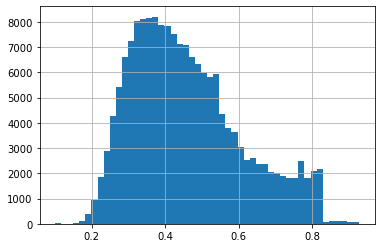

In [700]:
article_agenda_topic_similarity.max(axis=1).hist(bins=50)

In [710]:
article_agenda_topic_similarity.head(10).max(axis=1)

0    0.384870
1    0.660970
2    0.729649
3    0.368077
4    0.340287
5    0.519843
6    0.674591
7    0.641012
8    0.333920
9    0.376871
dtype: float64

In [711]:
article_agenda_topic_similarity.head(10).idxmax(axis=1)

0     26
1    126
2    126
3    745
4    250
5    919
6    919
7    919
8     26
9     26
dtype: int64

In [717]:
training_data.iloc[0]['normalized_text']

'Dental Health\n\nBraces aren\'t just for kids anymore. Lasers are no longer "future" dental tools. And cavities can be contagious. Orthodontics and dentistry are evolving, but some people, mostly children, fail to benefit from such advances. Learn about these topics and more -- including tips for children and even infants\' oral health -- in these articles from ORG.\n\nWORK_OF_ART toothpastes a bright idea? It\'s hard to believe, but there was a time not long ago when everyone walked around (in public!) with naturally colored teeth. DATE, with so many whitening gels, strips and trays out there, yellowish grins aren\'t as common — nor the natural look as appealing — as they used to be.\n\nMore homeless veterans getting dental care in GPE PERSON smiled into the mirror and saw a full set of pearly white teeth for the ORDINAL time in DATE.\n\nHow to get the most out of your toothbrush PERSON (and flossing) is the best way to protect your teeth and gums — but not if your toothbrush is in b

In [725]:
agenda_watch_df.iloc[26]['normalized_text']

'ABAG-BAAQMD-BCDC-ORG\nDATE NUM:NUM:NUM.NUM\nORG\nThis agenda was updated DATE. It is accurate to the best of our knowledge \nat that time. \nFor assistance, please contact PERSON, NUM.NUM.NUM\nORG meeting\nDATE NUM:NUM:NUM.NUM\nORG\njljljljlj'

<AxesSubplot:>

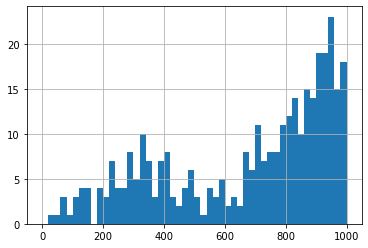

In [723]:
agenda_watch_df['normalized_text'].str.len().hist(bins=50, range=(0, 1000))

# Try Embedded Topic Model

In [681]:
from embedded_topic_model.utils import preprocessing

In [684]:
# Preprocessing the dataset
vocabulary, train_dataset, _, = preprocessing.create_etm_datasets(
    train_df['article_text'][:50], 
    min_df=0.01, 
    max_df=0.75, 
    train_size=0.85, 
)

In [691]:
from importlib import reload
reload(embedding)

<module 'embedded_topic_model.utils.embedding' from '/Users/spangher/opt/anaconda3/lib/python3.9/site-packages/embedded_topic_model/utils/embedding.py'>

In [ ]:
import gensim
reload(gensim)

In [ ]:
from embedded_topic_model.utils import embedding

# Training word2vec embeddings
embeddings_mapping = (
    embedding
    .create_word2vec_embedding_from_dataset(train_df['article_text'][:50].tolist(),)
)

In [299]:
import re

In [311]:
from zipfile import ZipFile
myzip = ZipFile('../data/sfchron-ten-years.zip')
files = list(map(lambda x: x.filename, myzip.filelist))

file_nums = list(map(lambda x: re.search('\d{14}', x), files))
file_nums = list(filter(lambda x: x is not None, file_nums))
file_nums = list(set(map(lambda x: x[0], file_nums)))

In [313]:
ls ../scripts-homepage-data/scrape_using_gcr/

gcr_playwright_files/ gcr_sf_files/
gcr_runner.py         index.html


In [315]:
with open('../scripts-homepage-data/scrape_using_gcr/sfchron-existing-wb-ids.txt', 'w') as f:
    for f_num in file_nums:
        f.write(f_num)
        f.write('\n')